# Unsupervised Autoregressive Protein Feature Embedding

Learn per-cell embeddings using a GRU-based autoregressive model on temporal protein expression sequences.
The model predicts next-step expression as a pretext task; the GRU hidden states are pooled to produce
fixed-size per-cell embeddings for measuring inter-cell expression distances.

In [4]:
import os
import json
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from scipy.stats import mannwhitneyu, ks_2samp, spearmanr, pearsonr
from scipy.spatial.distance import pdist, squareform
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score
import torch

BUNDLE_DIR = Path.cwd().resolve()
ROOT_DIR = BUNDLE_DIR.parents[0]
RESULTS_DIR = BUNDLE_DIR / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
DATA_DIR = ROOT_DIR / "data"
AGGREGATED_SCANPY_PATH = DATA_DIR / "protein" / "aggregated_scanpy.h5ad"
CELL_LINEAGE_PATH = DATA_DIR / "cell_lineage.json"
CELL_TYPE_PATH = DATA_DIR / "2023-06-29_entropy_cell_key_V2.csv"

if str(BUNDLE_DIR) not in sys.path:
    sys.path.insert(0, str(BUNDLE_DIR))
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

from autoregressive_embedding import (
    load_temporal_sequences,
    train_autoregressive,
    extract_embeddings,
    feature_importance,
 )

OUT_DIR = str(RESULTS_DIR)
os.makedirs(OUT_DIR, exist_ok=True)

## 1. Load & Inspect Data

Cells: 1322, Features: 266
Sequence lengths: min=3, max=246, mean=114.0, median=123.0


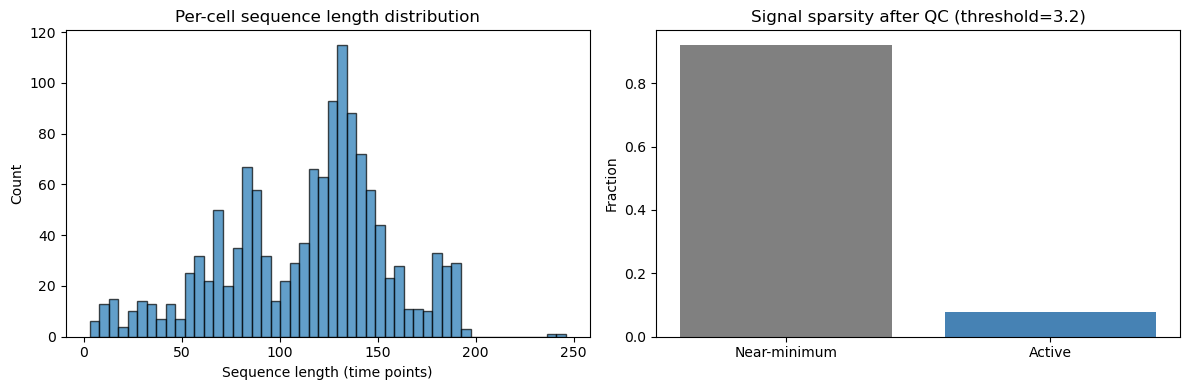

In [5]:
sequences, norm_params, feature_names = load_temporal_sequences(
    str(AGGREGATED_SCANPY_PATH), qc_threshold=3.2, min_seq_len=3
)
print(f"Cells: {len(sequences)}, Features: {len(feature_names)}")

seq_lens = np.array([len(s['times']) for s in sequences])
print(f"Sequence lengths: min={seq_lens.min()}, max={seq_lens.max()}, "
      f"mean={seq_lens.mean():.1f}, median={np.median(seq_lens):.1f}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(seq_lens, bins=50, edgecolor='k', alpha=0.7)
axes[0].set_xlabel('Sequence length (time points)')
axes[0].set_ylabel('Count')
axes[0].set_title('Per-cell sequence length distribution')

# Sparsity after QC
all_expr = np.concatenate([s['expression'] for s in sequences], axis=0)
# After normalization, zeros in raw become the z-scored value of log1p(0)=0
# Check fraction of near-zero values
zero_frac = (np.abs(all_expr - all_expr.min(axis=0)) < 1e-6).mean()
axes[1].bar(['Near-minimum', 'Active'], [zero_frac, 1 - zero_frac], color=['gray', 'steelblue'])
axes[1].set_ylabel('Fraction')
axes[1].set_title(f'Signal sparsity after QC (threshold=3.2)')
plt.tight_layout()
plt.show()

## 2. Train Autoregressive Model

In [4]:
model, history, copy_baseline = train_autoregressive(
    sequences,
    d_model=128,
    n_layers=2,
    dropout=0.1,
    n_epochs=200,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4,
    patience=20,
    seed=42,
)
print(f"\nCopy baseline MSE: {copy_baseline:.6f}")
print(f"Best val MSE: {min(history['val_loss']):.6f}")
print(f"Improvement over copy: {(1 - min(history['val_loss']) / copy_baseline) * 100:.1f}%")

  Epoch   0 | train 0.541256 | val 0.440733 | copy baseline 0.518411
  Epoch  20 | train 0.341008 | val 0.309717 | copy baseline 0.518411
  Epoch  40 | train 0.326397 | val 0.296137 | copy baseline 0.518411
  Epoch  60 | train 0.318376 | val 0.291113 | copy baseline 0.518411
  Epoch  80 | train 0.312983 | val 0.287745 | copy baseline 0.518411
  Epoch 100 | train 0.310152 | val 0.285913 | copy baseline 0.518411
  Epoch 120 | train 0.308220 | val 0.284668 | copy baseline 0.518411
  Epoch 140 | train 0.309682 | val 0.284021 | copy baseline 0.518411
  Epoch 160 | train 0.308421 | val 0.283738 | copy baseline 0.518411
  Epoch 180 | train 0.305889 | val 0.283560 | copy baseline 0.518411
  Epoch 199 | train 0.308289 | val 0.283560 | copy baseline 0.518411

Copy baseline MSE: 0.518411
Best val MSE: 0.283548
Improvement over copy: 45.3%


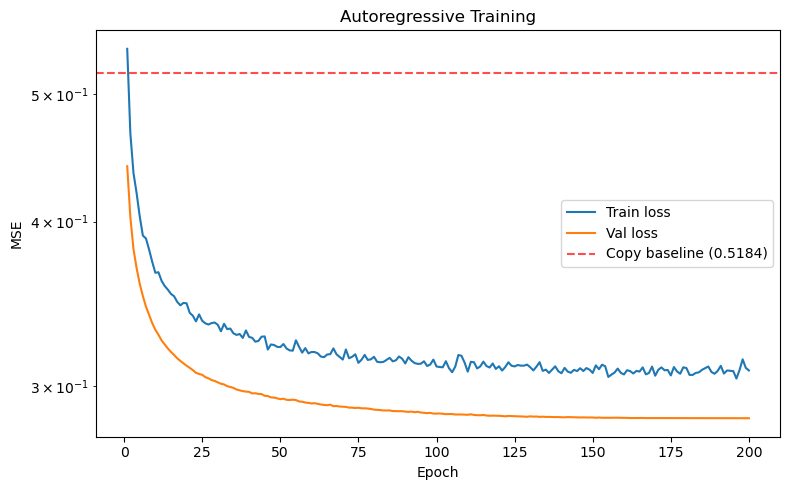

In [5]:
fig, ax = plt.subplots(figsize=(8, 5))
epochs = range(1, len(history['train_loss']) + 1)
ax.plot(epochs, history['train_loss'], label='Train loss')
ax.plot(epochs, history['val_loss'], label='Val loss')
ax.axhline(y=copy_baseline, color='r', linestyle='--', alpha=0.7, label=f'Copy baseline ({copy_baseline:.4f})')
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_title('Autoregressive Training')
ax.legend()
ax.set_yscale('log')
plt.tight_layout()
plt.show()

## 3. Extract Embeddings

In [6]:
cell_names, embeddings, pca = extract_embeddings(
    model, sequences, method='mean', embed_dim=32
)
cell_names = np.array(cell_names)
print(f"Embeddings shape: {embeddings.shape}")
print(f"PCA explained variance (first 5): {pca.explained_variance_ratio_[:5]}")
print(f"PCA total explained variance: {pca.explained_variance_ratio_.sum():.3f}")

Embeddings shape: (1322, 32)
PCA explained variance (first 5): [0.14547053 0.07925086 0.06078726 0.04632756 0.04583936]
PCA total explained variance: 0.775


## 4. Load Cell Types & Lineage Structure (for evaluation only)

In [ ]:
def map_names(did):
    if   did == "P4a": return "Z3"
    elif did == "P4p": return "Z2"
    elif did == "P0a": return "AB"
    else: return did

# Load lineage tree
with CELL_LINEAGE_PATH.open() as f:
    lineage_data = json.load(f)

# DFS to classify terminal vs intermediate
terminal_nodes = []
intermediate_nodes = []
descendant_list_dict = {}

def dfs_classify(node):
    name = map_names(node["did"])
    children = node.get("children", [])
    if not children:
        terminal_nodes.append(name)
        return [name]
    all_desc = []
    for c in children:
        all_desc.extend(dfs_classify(c))
    intermediate_nodes.append(name)
    descendant_list_dict[name] = all_desc
    return all_desc

dfs_classify(lineage_data)
print(f"Terminal: {len(terminal_nodes)}, Intermediate: {len(intermediate_nodes)}")

# Cell type labels
type_df = pd.read_csv(CELL_TYPE_PATH)
type_lookup = dict(zip(type_df["wormweb.lineage"], type_df["wormweb.type"]))

cell_type_dict = {}
for tn in terminal_nodes:
    ct = type_lookup.get(tn)
    if pd.isna(ct) or ct is None:
        ct = "programmed_death"
    cell_type_dict[tn] = ct

cell_types = sorted(set(cell_type_dict.values()) - {"programmed_death"})
cell_types.append("programmed_death")
print(f"Cell types ({len(cell_types)}): {cell_types}")

# Build parent/children map for sibling analysis
children_dict_lin = defaultdict(list)

def build_family(node, parent_name=None):
    name = map_names(node["did"])
    if parent_name is not None:
        children_dict_lin[parent_name].append(name)
    for child in node.get("children", []):
        build_family(child, name)

build_family(lineage_data)

# Map indices
cell_name_to_idx = {name: i for i, name in enumerate(cell_names)}
terminal_set = set(terminal_nodes) & set(cell_names)
print(f"Terminal cells with embeddings: {len(terminal_set)}")

Terminal: 1092, Intermediate: 1091
Cell types (18): ['coelomocyte', 'epithelium', 'excretory', 'gland', 'hypoderm', 'intestine', 'marginal', 'mesoderm', 'muscle', 'neuron', 'other', 'rectal', 'repro', 'sheath', 'socket', 'tail', 'valve', 'programmed_death']
Terminal cells with embeddings: 588


## 5. Sibling Distance Analysis

Same-type sibling pairs: 127
Diff-type sibling pairs: 128
Same-type dist: mean=0.4540, median=0.4357
Diff-type dist: mean=0.5102, median=0.5361
Cohen's d: 0.2090
Mann-Whitney U: stat=6567.0, p=4.03e-03
KS test: stat=0.2398, p=9.29e-04


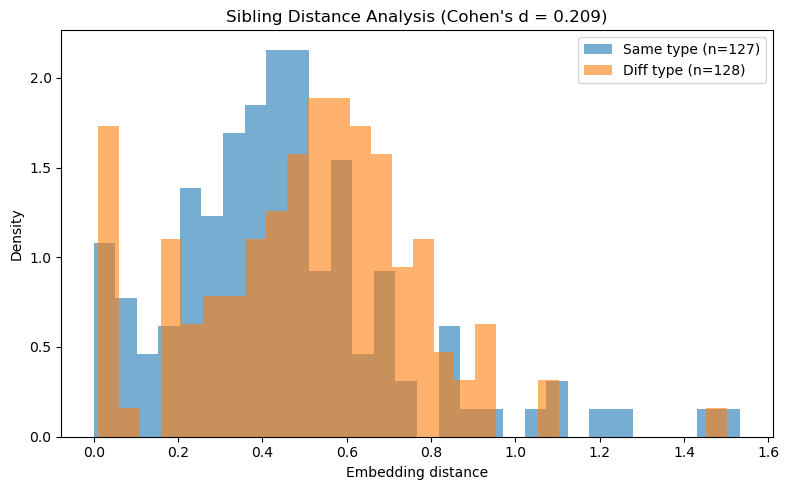

In [8]:
# Collect terminal sibling pairs
same_pairs, diff_pairs = [], []
for parent, children in children_dict_lin.items():
    term_children = [c for c in children if c in terminal_set]
    for i in range(len(term_children)):
        for j in range(i + 1, len(term_children)):
            a, b = term_children[i], term_children[j]
            type_a = cell_type_dict.get(a)
            type_b = cell_type_dict.get(b)
            if type_a is None or type_b is None:
                continue
            if type_a == type_b:
                same_pairs.append((a, b))
            else:
                diff_pairs.append((a, b))

def pair_distance(a, b):
    ia, ib = cell_name_to_idx[a], cell_name_to_idx[b]
    return float(np.linalg.norm(embeddings[ia] - embeddings[ib]))

same_dists = np.array([pair_distance(a, b) for a, b in same_pairs])
diff_dists = np.array([pair_distance(a, b) for a, b in diff_pairs])

print(f"Same-type sibling pairs: {len(same_pairs)}")
print(f"Diff-type sibling pairs: {len(diff_pairs)}")
print(f"Same-type dist: mean={same_dists.mean():.4f}, median={np.median(same_dists):.4f}")
print(f"Diff-type dist: mean={diff_dists.mean():.4f}, median={np.median(diff_dists):.4f}")

# Cohen's d
pooled_std = np.sqrt((same_dists.var() + diff_dists.var()) / 2)
cohens_d = (diff_dists.mean() - same_dists.mean()) / pooled_std
print(f"Cohen's d: {cohens_d:.4f}")

# Statistical tests
u_stat, u_p = mannwhitneyu(same_dists, diff_dists, alternative='less')
ks_stat, ks_p = ks_2samp(same_dists, diff_dists)
print(f"Mann-Whitney U: stat={u_stat:.1f}, p={u_p:.2e}")
print(f"KS test: stat={ks_stat:.4f}, p={ks_p:.2e}")

# Plot
fig, ax = plt.subplots(figsize=(8, 5))
ax.hist(same_dists, bins=30, alpha=0.6, label=f'Same type (n={len(same_dists)})', density=True)
ax.hist(diff_dists, bins=30, alpha=0.6, label=f'Diff type (n={len(diff_dists)})', density=True)
ax.set_xlabel('Embedding distance')
ax.set_ylabel('Density')
ax.set_title(f'Sibling Distance Analysis (Cohen\'s d = {cohens_d:.3f})')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Comparison with Supervised Embeddings

In [9]:
# Load supervised embeddings for comparison
sup_path = os.path.join(OUT_DIR, "embeddings_32d.csv")
if os.path.exists(sup_path):
    sup_df = pd.read_csv(sup_path, index_col=0)
    # Find common cells
    common = sorted(set(cell_names) & set(sup_df.index))
    print(f"Common cells: {len(common)}")
    
    ar_idx = [cell_name_to_idx[c] for c in common]
    ar_emb = embeddings[ar_idx]
    sup_emb = sup_df.loc[common].values
    
    # Pairwise distance correlation
    ar_dists = pdist(ar_emb)
    sup_dists = pdist(sup_emb)
    
    r_pearson, p_pearson = pearsonr(ar_dists, sup_dists)
    r_spearman, p_spearman = spearmanr(ar_dists, sup_dists)
    print(f"Pairwise distance correlation (Pearson):  r={r_pearson:.4f}, p={p_pearson:.2e}")
    print(f"Pairwise distance correlation (Spearman): r={r_spearman:.4f}, p={p_spearman:.2e}")
else:
    print(f"No supervised embeddings found at {sup_path}, skipping comparison.")

Common cells: 1204
Pairwise distance correlation (Pearson):  r=0.2111, p=0.00e+00
Pairwise distance correlation (Spearman): r=0.2667, p=0.00e+00


## 7. k-NN Cell Type Classification (Evaluation)

In [10]:
# Use terminal cell-type labels to evaluate embedding quality via k-NN
terminal_cells_with_emb = [c for c in terminal_set if c in cell_name_to_idx]
X_knn = np.array([embeddings[cell_name_to_idx[c]] for c in terminal_cells_with_emb])
y_knn = np.array([cell_type_dict[c] for c in terminal_cells_with_emb])

for k in [5, 10, 15]:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_knn, y_knn, cv=5, scoring='accuracy')
    print(f"k-NN (k={k:2d}): accuracy = {scores.mean():.3f} +/- {scores.std():.3f}")

k-NN (k= 5): accuracy = 0.633 +/- 0.057
k-NN (k=10): accuracy = 0.646 +/- 0.055
k-NN (k=15): accuracy = 0.646 +/- 0.026


/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(
/home/bingran/miniconda3/envs/dev/lib/python3.13/site-packages/sklearn/model_selection/_split.py:813: UserWarning: The least populated class in y has only 1 members, which is less than n_splits=5.
  warnings.warn(


## 8. PCA Visualization

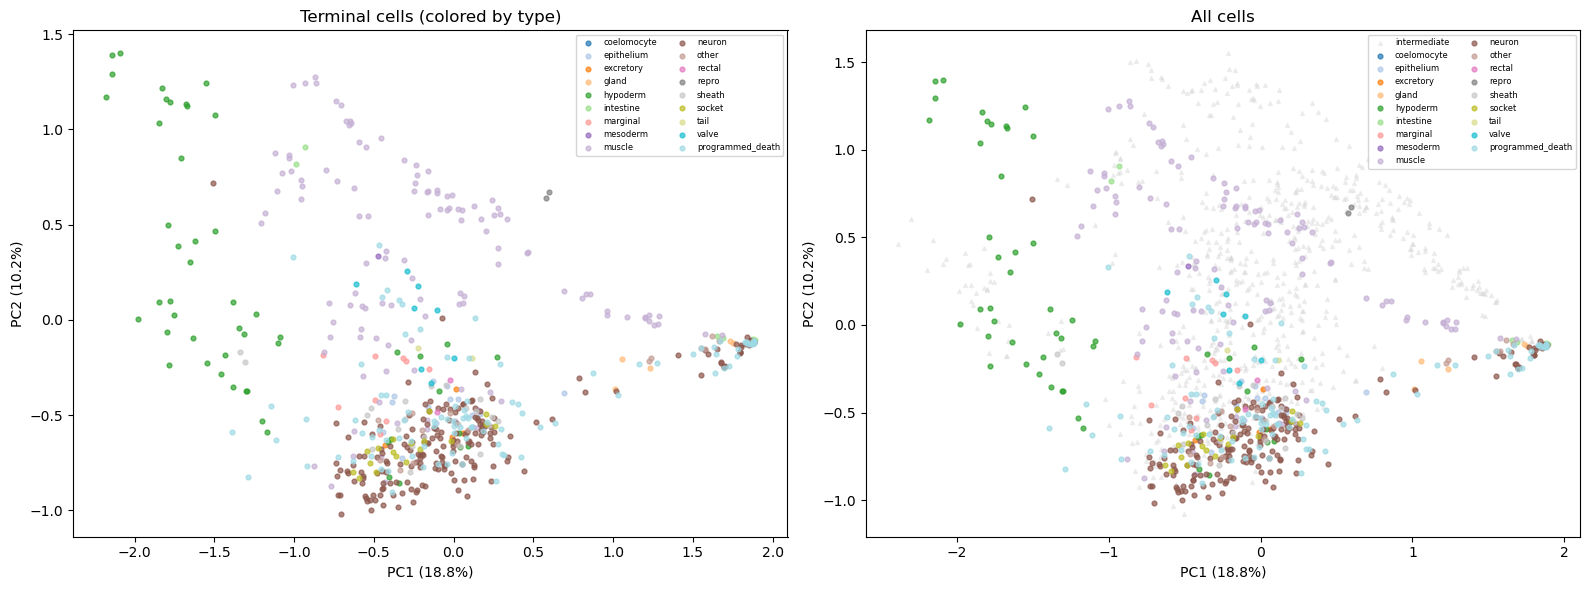

In [11]:
pca_vis = PCA(n_components=2)
emb_2d = pca_vis.fit_transform(embeddings)

cmap = plt.get_cmap('tab20', len(cell_types))
cell_type_colors = {ct: cmap(i) for i, ct in enumerate(cell_types)}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: terminal only
ax = axes[0]
for ct in cell_types:
    mask = np.array([cell_names[i] in terminal_set and cell_type_dict.get(cell_names[i]) == ct
                     for i in range(len(cell_names))])
    if mask.sum() == 0:
        continue
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[cell_type_colors[ct]],
              s=12, alpha=0.7, label=ct)
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.1%})')
ax.set_title('Terminal cells (colored by type)')
ax.legend(fontsize=6, ncol=2, loc='best')

# Right: all cells
ax = axes[1]
# Intermediate as grey
inter_mask = np.array([cell_names[i] not in terminal_set for i in range(len(cell_names))])
ax.scatter(emb_2d[inter_mask, 0], emb_2d[inter_mask, 1], c='lightgray',
          s=8, alpha=0.3, marker='^', label='intermediate')
for ct in cell_types:
    mask = np.array([cell_names[i] in terminal_set and cell_type_dict.get(cell_names[i]) == ct
                     for i in range(len(cell_names))])
    if mask.sum() == 0:
        continue
    ax.scatter(emb_2d[mask, 0], emb_2d[mask, 1], c=[cell_type_colors[ct]],
              s=12, alpha=0.7, label=ct)
ax.set_xlabel(f'PC1 ({pca_vis.explained_variance_ratio_[0]:.1%})')
ax.set_ylabel(f'PC2 ({pca_vis.explained_variance_ratio_[1]:.1%})')
ax.set_title('All cells')
ax.legend(fontsize=6, ncol=2, loc='best')

plt.tight_layout()
plt.show()

## 9. Feature Importance

Top 25 TFs by input projection importance:
   1. HBL-1         (importance=1.0417)
   2. MEP-1         (importance=0.9951)
   3. HLH-1         (importance=0.9524)
   4. EGL-18        (importance=0.9237)
   5. CEH-38        (importance=0.9080)
   6. LIN-15B       (importance=0.8993)
   7. ALY-2         (importance=0.8987)
   8. LSY-2         (importance=0.8683)
   9. ZTF-6         (importance=0.8630)
  10. EFL-1         (importance=0.8526)
  11. ALY-1         (importance=0.8465)
  12. CEH-43        (importance=0.8399)
  13. HMG-4         (importance=0.8361)
  14. SPTF-1        (importance=0.8326)
  15. TAB-1         (importance=0.8206)
  16. UNC-37        (importance=0.8160)
  17. CEH-36        (importance=0.8141)
  18. DVE-1         (importance=0.8125)
  19. CEH-27        (importance=0.8061)
  20. F19F10.9      (importance=0.7956)
  21. VAB-7         (importance=0.7933)
  22. LIN-39        (importance=0.7867)
  23. NHR-25        (importance=0.7849)
  24. UNC-120       (importance=0.783

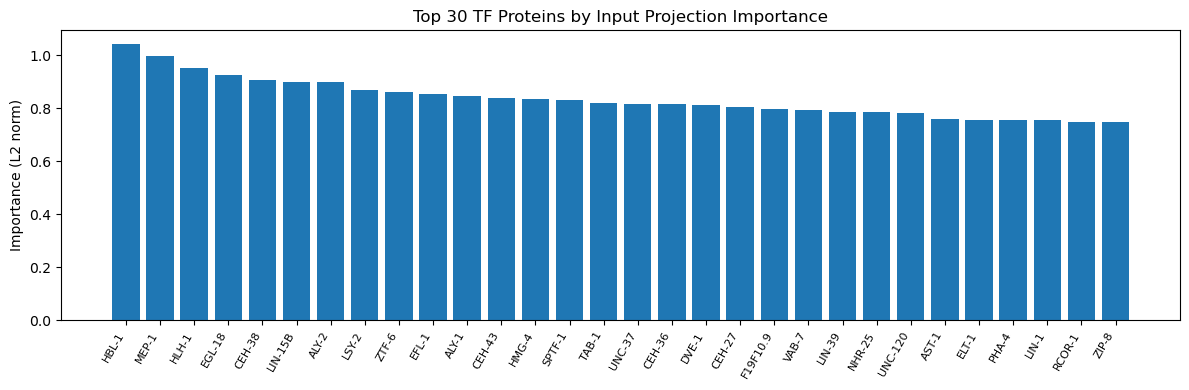

In [12]:
importance = feature_importance(model)
ranked_idx = np.argsort(importance)[::-1]

print("Top 25 TFs by input projection importance:")
for i, idx in enumerate(ranked_idx[:25]):
    print(f"  {i+1:2d}. {feature_names[idx]:12s}  (importance={importance[idx]:.4f})")

fig, ax = plt.subplots(figsize=(12, 4))
top_n = 30
ax.bar(range(top_n), importance[ranked_idx[:top_n]])
ax.set_xticks(range(top_n))
ax.set_xticklabels(feature_names[ranked_idx[:top_n]], rotation=60, ha='right', fontsize=8)
ax.set_ylabel('Importance (L2 norm)')
ax.set_title('Top 30 TF Proteins by Input Projection Importance')
plt.tight_layout()
plt.show()

## 10. Save Outputs

In [13]:
# Save embeddings
embed_dim = embeddings.shape[1]
emb_cols = [f'emb_{i}' for i in range(embed_dim)]
emb_df = pd.DataFrame(embeddings, index=cell_names, columns=emb_cols)
emb_df.index.name = 'cell_name'
emb_path = os.path.join(OUT_DIR, f'ar_embeddings_{embed_dim}d.csv')
emb_df.to_csv(emb_path)
print(f"Saved embeddings: {emb_path} (shape: {emb_df.shape})")

# Save feature importance
imp_path = os.path.join(OUT_DIR, 'ar_feature_importance.tsv')
pd.Series(feature_names[ranked_idx]).to_csv(imp_path, sep='\t', index=False, header=False)
print(f"Saved feature importance: {imp_path}")

# Save model checkpoint
ckpt_path = os.path.join(OUT_DIR, 'ar_model_checkpoint.pt')
torch.save({
    'model_state_dict': model.state_dict(),
    'norm_params': {k: v.tolist() if isinstance(v, np.ndarray) else v
                    for k, v in norm_params.items()},
    'feature_names': feature_names.tolist(),
    'config': {
        'n_features': len(feature_names),
        'd_model': 128,
        'n_layers': 2,
        'dropout': 0.1,
    },
    'history': history,
    'copy_baseline': copy_baseline,
}, ckpt_path)
print(f"Saved checkpoint: {ckpt_path}")

Saved embeddings: ./data/protein/aggregated_all/ar_embeddings_32d.csv (shape: (1322, 32))
Saved feature importance: ./data/protein/aggregated_all/ar_feature_importance.tsv
Saved checkpoint: ./data/protein/aggregated_all/ar_model_checkpoint.pt
